In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
# # 1. Install the wandb library
# !pip install wandb -qU

# # 2. Import and log in
# import os
# import wandb
# from kaggle_secrets import UserSecretsClient

# user_secrets = UserSecretsClient()
# wandb_key = user_secrets.get_secret("WANDB_API_KEY")

# # Log in to W&B
# wandb.login(key=wandb_key)

# # 3. Initialize W&B run
# wandb.init(
#     project="22f3001418-t22026", 
#     name="Initial Setup",      
#     config={
#         "stage": "Initial Setup",
#         "dataset": "Genre_Mashup"
#     }
# )
# print('done')

# EDA

In [3]:
# config.py
# Central configuration file for Smart MCQ Solver
# Edit these values to customize behavior across all modules

import os

# ------------------------------------------------------------------
# PATHS
# ------------------------------------------------------------------
DATA_DIR        = "data"
OUTPUT_DIR      = "outputs"
MODEL_DIR       = "models"

TRAIN_PATH      = os.path.join(DATA_DIR, "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
TEST_PATH       = os.path.join(DATA_DIR, "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
SUBMISSION_PATH = os.path.join(DATA_DIR, "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

# ------------------------------------------------------------------
# COLUMN NAMES
# ------------------------------------------------------------------
ID_COL      = "id"
PROMPT_COL  = "prompt"
ANSWER_COL  = "answer"
OPTION_COLS = ["A", "B", "C", "D", "E"]
TEXT_COLS   = [PROMPT_COL] + OPTION_COLS

# ------------------------------------------------------------------
# TEXT PREPROCESSING
# ------------------------------------------------------------------
REMOVE_STOPWORDS = True
LEMMATIZE        = True
STEM             = False
MIN_TOKEN_LENGTH = 2

# ------------------------------------------------------------------
# TF-IDF SETTINGS
# ------------------------------------------------------------------
TFIDF_MAX_FEATURES = 5000
TFIDF_NGRAM_RANGE  = (1, 2)
TFIDF_MIN_DF       = 1
TFIDF_MAX_DF       = 0.95
TFIDF_SUBLINEAR_TF = True

# ------------------------------------------------------------------
# WORD2VEC SETTINGS
# ------------------------------------------------------------------
W2V_VECTOR_SIZE = 100
W2V_WINDOW      = 5
W2V_MIN_COUNT   = 1
W2V_SG          = 1        # 1 = Skip-gram, 0 = CBOW
W2V_EPOCHS      = 10
W2V_WORKERS     = 4
W2V_SEED        = 42

# ------------------------------------------------------------------
# GENERAL
# ------------------------------------------------------------------
RANDOM_SEED = 42
TOP_K       = 3            # MAP@K evaluation

# ------------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------------
PLOT_STYLE  = "seaborn-v0_8-whitegrid"
COLORS      = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B"]
FIGURE_DPI  = 150
SAVE_PLOTS  = True
print("done")

done


In [4]:
# data_loader.py
# Handles all data loading and basic validation

import os
import pandas as pd
import numpy as np

# from config import (
#     TRAIN_PATH, TEST_PATH, SUBMISSION_PATH,
#     ID_COL, PROMPT_COL, ANSWER_COL, OPTION_COLS, TEXT_COLS
# )


# ------------------------------------------------------------------
# CORE LOADER
# ------------------------------------------------------------------

def load_csv(filepath: str) -> pd.DataFrame:
    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"File not found: {filepath}\n"
            f"Make sure the file exists at the specified path."
        )
    df = pd.read_csv(filepath)
    print(f"Loaded  : {filepath}")
    print(f"Shape   : {df.shape}")
    return df


def load_train(path: str = TRAIN_PATH) -> pd.DataFrame:
    """Load training data."""
    return load_csv(path)


def load_test(path: str = TEST_PATH) -> pd.DataFrame:
    """Load test data."""
    return load_csv(path)


def load_submission(path: str = SUBMISSION_PATH) -> pd.DataFrame:
    """Load sample submission file."""
    return load_csv(path)


# ------------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------------

def validate_dataframe(df: pd.DataFrame,
                        required_cols: list,
                        name: str = "DataFrame") -> bool:
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f"{name} is missing columns: {missing_cols}\n"
            f"Available columns: {df.columns.tolist()}"
        )
    print(f"{name} validation passed. All required columns present.")
    return True


def check_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    missing_count = df.isnull().sum()
    missing_pct   = (missing_count / len(df) * 100).round(2)
    report = pd.DataFrame({
        "missing_count": missing_count,
        "missing_pct"  : missing_pct
    })
    report = report[report["missing_count"] > 0].sort_values(
        "missing_count", ascending=False
    )
    return report


def fill_missing_text(df: pd.DataFrame,
                       text_cols: list = None,
                       fill_value: str = "") -> pd.DataFrame:
    if text_cols is None:
        text_cols = TEXT_COLS

    df = df.copy()
    for col in text_cols:
        if col in df.columns:
            n_missing = df[col].isnull().sum()
            if n_missing > 0:
                df[col] = df[col].fillna(fill_value)
                print(f"Filled {n_missing} missing values in column '{col}'")
    return df


# ------------------------------------------------------------------
# BASIC STATISTICS
# ------------------------------------------------------------------

def basic_stats(df: pd.DataFrame) -> dict:
    stats = {
        "n_rows"         : len(df),
        "n_cols"         : len(df.columns),
        "columns"        : df.columns.tolist(),
        "dtypes"         : df.dtypes.to_dict(),
        "memory_kb"      : df.memory_usage(deep=True).sum() / 1024,
        "total_missing"  : df.isnull().sum().sum(),
    }

    if ANSWER_COL in df.columns:
        stats["answer_distribution"] = df[ANSWER_COL].value_counts().to_dict()

    return stats


def print_basic_stats(df: pd.DataFrame, name: str = "Dataset") -> None:
    stats = basic_stats(df)
    separator = "-" * 40
    print(separator)
    print(f"BASIC STATS : {name}")
    print(separator)
    print(f"Rows        : {stats['n_rows']:,}")
    print(f"Columns     : {stats['n_cols']}")
    print(f"Memory      : {stats['memory_kb']:.2f} KB")
    print(f"Missing     : {stats['total_missing']}")
    if "answer_distribution" in stats:
        print(f"Answer Dist : {stats['answer_distribution']}")
    print(separator)

print("done")

done


In [5]:
# preprocessing.py
# All text cleaning, tokenization, and feature engineering functions

import re
import string
import pandas as pd
import numpy as np

import nltk
nltk.download("punkt",                    quiet=True)
nltk.download("punkt_tab",               quiet=True)
nltk.download("stopwords",               quiet=True)
nltk.download("wordnet",                 quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer, PorterStemmer

# from config import (
#     OPTION_COLS, TEXT_COLS, PROMPT_COL,
#     REMOVE_STOPWORDS, LEMMATIZE, STEM, MIN_TOKEN_LENGTH
# )


# ------------------------------------------------------------------
# SHARED OBJECTS  (instantiate once, reuse everywhere)
# ------------------------------------------------------------------
STOP_WORDS  = set(stopwords.words("english"))
LEMMATIZER  = WordNetLemmatizer()
STEMMER     = PorterStemmer()


# ------------------------------------------------------------------
# LOW-LEVEL CLEANING HELPERS
# ------------------------------------------------------------------

def remove_urls(text: str) -> str:
    """Remove http/https URLs and bare www addresses."""
    return re.sub(r"http\S+|www\S+|https\S+", " ", text)


def remove_emails(text: str) -> str:
    """Remove email addresses."""
    return re.sub(r"\S+@\S+", " ", text)


def remove_special_characters(text: str) -> str:
    """Keep only letters, digits, and whitespace."""
    return re.sub(r"[^a-z0-9\s]", " ", text)


def remove_digits(text: str) -> str:
    """Remove standalone digit sequences."""
    return re.sub(r"\b\d+\b", " ", text)


def normalize_whitespace(text: str) -> str:
    """Collapse multiple spaces into one and strip ends."""
    return re.sub(r"\s+", " ", text).strip()


# ------------------------------------------------------------------
# TOKENIZATION
# ------------------------------------------------------------------

def tokenize(text: str) -> list:
    """
    Tokenize text using NLTK word_tokenize.
    
    Usage:
        tokens = tokenize("Martin Heidegger's view on time.")
        # ['Martin', 'Heidegger', "'s", 'view', 'on', 'time', '.']
    """
    if not isinstance(text, str) or text.strip() == "":
        return []
    return word_tokenize(text)


def tokenize_clean(text: str) -> list:
    """
    Tokenize already-cleaned (lowercase) text, filtering short tokens.
    
    Usage:
        tokens = tokenize_clean("martin heidegger view time")
        # ['martin', 'heidegger', 'view', 'time']
    """
    if not isinstance(text, str) or text.strip() == "":
        return []
    return [
        t for t in word_tokenize(text)
        if len(t) >= MIN_TOKEN_LENGTH
    ]


# ------------------------------------------------------------------
# FULL CLEANING PIPELINE
# ------------------------------------------------------------------

def clean_text(text: str,
               remove_stopwords: bool = REMOVE_STOPWORDS,
               lemmatize: bool        = LEMMATIZE,
               stem: bool             = STEM) -> str:
    """
    Full NLP text cleaning pipeline:
        1. Lowercase
        2. Remove URLs, emails
        3. Remove special characters
        4. Remove digits
        5. Tokenize
        6. Remove stopwords (optional)
        7. Lemmatize (optional)
        8. Stem (optional, applied after lemmatize)
        9. Rejoin tokens

    Args:
        text             : raw input string
        remove_stopwords : whether to drop NLTK English stopwords
        lemmatize        : whether to apply WordNet lemmatization
        stem             : whether to apply Porter stemming

    Returns:
        Cleaned string.

    Usage:
        cleaned = clean_text("What is Martin Heidegger's view on time?")
        # "martin heidegger view time"
    """
    if not isinstance(text, str) or text.strip() == "":
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs and emails
    text = remove_urls(text)
    text = remove_emails(text)

    # 3. Remove special characters
    text = remove_special_characters(text)

    # 4. Remove digit-only tokens
    text = remove_digits(text)

    # 5. Normalize whitespace
    text = normalize_whitespace(text)

    # 6. Tokenize
    tokens = word_tokenize(text)

    # 7. Filter short tokens
    tokens = [t for t in tokens if len(t) >= MIN_TOKEN_LENGTH]

    # 8. Remove stopwords
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP_WORDS]

    # 9. Lemmatize
    if lemmatize:
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]

    # 10. Stem
    if stem:
        tokens = [STEMMER.stem(t) for t in tokens]

    return " ".join(tokens)


# ------------------------------------------------------------------
# BATCH CLEANING
# ------------------------------------------------------------------

def clean_series(series: pd.Series,
                 remove_stopwords: bool = REMOVE_STOPWORDS,
                 lemmatize: bool        = LEMMATIZE,
                 stem: bool             = STEM) -> pd.Series:
    """
    Apply clean_text to every element of a pandas Series.
    
    Usage:
        train_df["prompt_clean"] = clean_series(train_df["prompt"])
    """
    return series.apply(
        lambda x: clean_text(x, remove_stopwords, lemmatize, stem)
    )


def clean_dataframe(df: pd.DataFrame,
                    cols: list         = None,
                    suffix: str        = "_clean",
                    remove_stopwords: bool = REMOVE_STOPWORDS,
                    lemmatize: bool        = LEMMATIZE,
                    stem: bool             = STEM) -> pd.DataFrame:
    """
    Apply clean_text to specified columns and store results as
    new columns with a suffix appended.

    Args:
        df               : input DataFrame
        cols             : list of column names to clean (default: TEXT_COLS)
        suffix           : suffix for new cleaned columns
        remove_stopwords : passed to clean_text
        lemmatize        : passed to clean_text
        stem             : passed to clean_text

    Returns:
        DataFrame with additional cleaned columns.

    Usage:
        train_df = clean_dataframe(train_df, cols=TEXT_COLS)
        # Creates: prompt_clean, A_clean, B_clean, ...
    """
    if cols is None:
        cols = TEXT_COLS

    df = df.copy()
    for col in cols:
        if col in df.columns:
            new_col     = f"{col}{suffix}"
            df[new_col] = clean_series(
                df[col], remove_stopwords, lemmatize, stem
            )
            print(f"Cleaned column '{col}' -> '{new_col}'")
    return df


# ------------------------------------------------------------------
# TEXT STATISTICS
# ------------------------------------------------------------------

def text_length_stats(text: str) -> dict:
    """
    Compute character count, raw word count, and unique word count
    for a single string.
    
    Usage:
        stats = text_length_stats("What is fusion?")
        # {'char_count': 15, 'word_count': 3, 'unique_words': 3}
    """
    if not isinstance(text, str):
        return {"char_count": 0, "word_count": 0, "unique_words": 0}

    tokens = word_tokenize(text.lower())
    return {
        "char_count"  : len(text),
        "word_count"  : len(tokens),
        "unique_words": len(set(tokens))
    }


def add_text_length_features(df: pd.DataFrame,
                              cols: list = None) -> pd.DataFrame:
    """
    Add character count and word count columns for each specified column.

    Usage:
        train_df = add_text_length_features(train_df, TEXT_COLS)
        # Creates: prompt_char_len, prompt_word_len, A_char_len, ...
    """
    if cols is None:
        cols = TEXT_COLS

    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[f"{col}_char_len"] = df[col].apply(
                lambda x: len(str(x))
            )
            df[f"{col}_word_len"] = df[col].apply(
                lambda x: len(str(x).split())
            )
    return df


# ------------------------------------------------------------------
# CORPUS BUILDER (for embedding training)
# ------------------------------------------------------------------

def build_corpus(df: pd.DataFrame,
                 cols: list = None,
                 clean: bool = True) -> list:
    """
    Build a flat list of cleaned text strings from DataFrame columns.
    One string per (row, column) combination.
    Useful as input for TF-IDF or Word2Vec training.

    Args:
        df    : input DataFrame
        cols  : columns to include (default: TEXT_COLS)
        clean : whether to clean text before adding to corpus

    Returns:
        List of strings.

    Usage:
        corpus = build_corpus(train_df, TEXT_COLS)
    """
    if cols is None:
        cols = TEXT_COLS

    corpus = []
    for _, row in df.iterrows():
        for col in cols:
            if col in df.columns:
                text = str(row[col])
                corpus.append(clean_text(text) if clean else text)
    return corpus


def build_row_corpus(df: pd.DataFrame,
                     cols: list = None,
                     clean: bool = True) -> list:
    """
    Build a list of strings where each string is the concatenation
    of all specified column values for one row.
    One string per row.

    Usage:
        row_corpus = build_row_corpus(train_df, TEXT_COLS)
        # len(row_corpus) == len(train_df)
    """
    if cols is None:
        cols = TEXT_COLS

    corpus = []
    for _, row in df.iterrows():
        parts    = [str(row[col]) for col in cols if col in df.columns]
        combined = " ".join(parts)
        corpus.append(clean_text(combined) if clean else combined)
    return corpus


def build_token_sentences(df: pd.DataFrame,
                          cols: list = None) -> list:
    """
    Build a list of token lists for Word2Vec training.
    Each element is a list of tokens from one (row, column) pair.

    Usage:
        sentences = build_token_sentences(train_df, TEXT_COLS)
        w2v = Word2Vec(sentences=sentences, ...)
    """
    if cols is None:
        cols = TEXT_COLS

    from gensim.utils import simple_preprocess

    sentences = []
    for _, row in df.iterrows():
        for col in cols:
            if col in df.columns:
                tokens = simple_preprocess(str(row[col]))
                if tokens:
                    sentences.append(tokens)
    return sentences
print("done")

done


In [6]:
# embeddings.py
# TF-IDF and Word2Vec embedding generation and utilities

import os
import pickle
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition           import PCA, TruncatedSVD

from gensim.models  import Word2Vec
from gensim.utils   import simple_preprocess

# from config import (
#     TFIDF_MAX_FEATURES, TFIDF_NGRAM_RANGE, TFIDF_MIN_DF,
#     TFIDF_MAX_DF, TFIDF_SUBLINEAR_TF,
#     W2V_VECTOR_SIZE, W2V_WINDOW, W2V_MIN_COUNT,
#     W2V_SG, W2V_EPOCHS, W2V_WORKERS, W2V_SEED,
#     OPTION_COLS, PROMPT_COL, MODEL_DIR
# )
# from preprocessing import (
#     clean_text, build_row_corpus, build_token_sentences
# )


# ------------------------------------------------------------------
# TF-IDF
# ------------------------------------------------------------------

class TFIDFEmbedder:
    """
    Wrapper around sklearn TfidfVectorizer for the MCQ pipeline.

    Usage:
        embedder = TFIDFEmbedder()
        embedder.fit(corpus)                     # corpus = list of strings
        matrix  = embedder.transform(corpus)    # scipy sparse matrix
        vec     = embedder.transform_one("some text")
    """

    def __init__(self,
                 max_features: int  = TFIDF_MAX_FEATURES,
                 ngram_range: tuple = TFIDF_NGRAM_RANGE,
                 min_df: int        = TFIDF_MIN_DF,
                 max_df: float      = TFIDF_MAX_DF,
                 sublinear_tf: bool = TFIDF_SUBLINEAR_TF):

        self.vectorizer = TfidfVectorizer(
            max_features = max_features,
            ngram_range  = ngram_range,
            min_df       = min_df,
            max_df       = max_df,
            sublinear_tf = sublinear_tf
        )
        self.is_fitted = False

    def fit(self, corpus: list) -> "TFIDFEmbedder":
        """
        Fit the TF-IDF vocabulary on a list of text strings.

        Usage:
            embedder.fit(corpus)
        """
        self.vectorizer.fit(corpus)
        self.is_fitted = True
        print(f"TF-IDF fitted  | vocab size : {len(self.vectorizer.vocabulary_)}")
        return self

    def transform(self, corpus: list):
        """
        Transform a list of strings into a sparse TF-IDF matrix.

        Usage:
            matrix = embedder.transform(corpus)
            # shape: (n_docs, max_features)
        """
        self._check_fitted()
        return self.vectorizer.transform(corpus)

    def fit_transform(self, corpus: list):
        """Fit and transform in one step."""
        self.fit(corpus)
        return self.transform(corpus)

    def transform_one(self, text: str):
        """
        Transform a single string into a sparse TF-IDF vector.

        Usage:
            vec = embedder.transform_one("What is fusion?")
        """
        self._check_fitted()
        cleaned = clean_text(text)
        return self.vectorizer.transform([cleaned])

    def get_feature_names(self) -> np.ndarray:
        """Return feature (token) names."""
        self._check_fitted()
        return self.vectorizer.get_feature_names_out()

    def top_features(self, n: int = 20) -> pd.DataFrame:
        """
        Return the n features with the highest mean TF-IDF score
        across the fitted corpus.

        Usage:
            top_df = embedder.top_features(20)
        """
        self._check_fitted()
        # Requires re-transforming the training corpus, store mean
        # during fit_transform if needed.
        raise NotImplementedError(
            "Call top_features_from_matrix(matrix, n) instead."
        )

    def save(self, path: str) -> None:
        """
        Save the fitted vectorizer to disk.

        Usage:
            embedder.save("models/tfidf.pkl")
        """
        with open(path, "wb") as f:
            pickle.dump(self.vectorizer, f)
        print(f"TF-IDF saved to {path}")

    def load(self, path: str) -> "TFIDFEmbedder":
        """
        Load a previously saved vectorizer from disk.

        Usage:
            embedder = TFIDFEmbedder().load("models/tfidf.pkl")
        """
        with open(path, "rb") as f:
            self.vectorizer = pickle.load(f)
        self.is_fitted = True
        print(f"TF-IDF loaded from {path}")
        return self

    def _check_fitted(self) -> None:
        if not self.is_fitted:
            raise RuntimeError("TFIDFEmbedder is not fitted yet. Call .fit() first.")


def top_features_from_matrix(matrix, feature_names: np.ndarray,
                              n: int = 20) -> pd.DataFrame:
    """
    Compute the top-n features by mean TF-IDF score across all documents.

    Args:
        matrix        : sparse TF-IDF matrix (n_docs x vocab)
        feature_names : array of feature names from TFIDFEmbedder.get_feature_names()
        n             : number of top features to return

    Returns:
        DataFrame with columns ['feature', 'mean_tfidf'].

    Usage:
        top_df = top_features_from_matrix(matrix, embedder.get_feature_names(), 20)
    """
    mean_scores = np.asarray(matrix.mean(axis=0)).flatten()
    top_indices = mean_scores.argsort()[-n:][::-1]
    return pd.DataFrame({
        "feature"    : feature_names[top_indices],
        "mean_tfidf" : mean_scores[top_indices]
    })


# ------------------------------------------------------------------
# WORD2VEC
# ------------------------------------------------------------------

class Word2VecEmbedder:
    """
    Wrapper around Gensim Word2Vec for the MCQ pipeline.

    Usage:
        embedder = Word2VecEmbedder()
        embedder.fit(sentences)               # sentences = list of token lists
        vec = embedder.get_word_vector("time")
        doc_vec = embedder.get_doc_vector("Martin Heidegger's view on time")
    """

    def __init__(self,
                 vector_size: int = W2V_VECTOR_SIZE,
                 window: int      = W2V_WINDOW,
                 min_count: int   = W2V_MIN_COUNT,
                 sg: int          = W2V_SG,
                 epochs: int      = W2V_EPOCHS,
                 workers: int     = W2V_WORKERS,
                 seed: int        = W2V_SEED):

        self.vector_size = vector_size
        self.window      = window
        self.min_count   = min_count
        self.sg          = sg
        self.epochs      = epochs
        self.workers     = workers
        self.seed        = seed
        self.model       = None

    def fit(self, sentences: list) -> "Word2VecEmbedder":
        """
        Train Word2Vec on a list of token lists.

        Args:
            sentences : list of lists of string tokens

        Usage:
            sentences = build_token_sentences(train_df, TEXT_COLS)
            embedder.fit(sentences)
        """
        self.model = Word2Vec(
            sentences   = sentences,
            vector_size = self.vector_size,
            window      = self.window,
            min_count   = self.min_count,
            sg          = self.sg,
            epochs      = self.epochs,
            workers     = self.workers,
            seed        = self.seed
        )
        print(f"Word2Vec trained | vocab size : {len(self.model.wv.key_to_index)}")
        return self

    def get_word_vector(self, word: str) -> np.ndarray:
        """
        Return the embedding vector for a single word.
        Returns a zero vector if the word is not in the vocabulary.

        Usage:
            vec = embedder.get_word_vector("fusion")
        """
        self._check_fitted()
        if word in self.model.wv:
            return self.model.wv[word]
        return np.zeros(self.vector_size)

    def get_doc_vector(self, text: str) -> np.ndarray:
        """
        Compute a document embedding by mean-pooling word vectors.
        Words absent from the vocabulary are ignored.
        Returns a zero vector if no word is in the vocabulary.

        Usage:
            doc_vec = embedder.get_doc_vector("What is accelerator based fusion?")
        """
        self._check_fitted()
        tokens  = simple_preprocess(str(text))
        vectors = [
            self.model.wv[t] for t in tokens if t in self.model.wv
        ]
        if not vectors:
            return np.zeros(self.vector_size)
        return np.mean(vectors, axis=0)

    def get_doc_vectors_batch(self, texts: list) -> np.ndarray:
        """
        Compute document embeddings for a list of strings.

        Returns:
            np.ndarray of shape (len(texts), vector_size)

        Usage:
            vecs = embedder.get_doc_vectors_batch(train_df["prompt"].tolist())
        """
        return np.vstack([self.get_doc_vector(t) for t in texts])

    def most_similar(self, word: str, topn: int = 5) -> list:
        """
        Return the most similar words to a given word.

        Usage:
            similar = embedder.most_similar("fusion", topn=5)
        """
        self._check_fitted()
        if word not in self.model.wv:
            print(f"Word '{word}' not in vocabulary.")
            return []
        return self.model.wv.most_similar(word, topn=topn)

    def save(self, path: str) -> None:
        """
        Save the trained Word2Vec model to disk.

        Usage:
            embedder.save("models/w2v.model")
        """
        self._check_fitted()
        self.model.save(path)
        print(f"Word2Vec saved to {path}")

    def load(self, path: str) -> "Word2VecEmbedder":
        """
        Load a previously saved Word2Vec model from disk.

        Usage:
            embedder = Word2VecEmbedder().load("models/w2v.model")
        """
        self.model = Word2Vec.load(path)
        print(f"Word2Vec loaded from {path}")
        return self

    def _check_fitted(self) -> None:
        if self.model is None:
            raise RuntimeError(
                "Word2VecEmbedder is not fitted yet. Call .fit() first."
            )


# ------------------------------------------------------------------
# DIMENSIONALITY REDUCTION
# ------------------------------------------------------------------

def reduce_with_pca(matrix: np.ndarray,
                    n_components: int = 2,
                    seed: int         = 42) -> tuple:
    """
    Reduce a dense embedding matrix to n_components dimensions using PCA.

    Returns:
        (reduced_matrix, pca_object)

    Usage:
        reduced, pca = reduce_with_pca(word_vectors, n_components=2)
    """
    pca     = PCA(n_components=n_components, random_state=seed)
    reduced = pca.fit_transform(matrix)
    print(f"PCA | explained variance : "
          f"{pca.explained_variance_ratio_.sum()*100:.2f}%")
    return reduced, pca


def reduce_with_svd(sparse_matrix,
                    n_components: int = 2,
                    seed: int         = 42) -> tuple:
    """
    Reduce a sparse TF-IDF matrix using TruncatedSVD (LSA).

    Returns:
        (reduced_matrix, svd_object)

    Usage:
        reduced, svd = reduce_with_svd(tfidf_matrix, n_components=2)
    """
    svd     = TruncatedSVD(n_components=n_components, random_state=seed)
    reduced = svd.fit_transform(sparse_matrix)
    print(f"SVD | explained variance : "
          f"{svd.explained_variance_ratio_.sum()*100:.2f}%")
    return reduced, svd
print("done")

done


In [7]:
# similarity.py
# Cosine similarity computation between prompts and answer options

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# from config       import OPTION_COLS, PROMPT_COL
# from preprocessing import clean_text


# ------------------------------------------------------------------
# CORE SIMILARITY FUNCTION
# ------------------------------------------------------------------

def cosine_sim(vec_a: np.ndarray,
               vec_b: np.ndarray) -> float:
    """
    Compute cosine similarity between two 1-D or 2-D numpy arrays.

    Formula:
        cos(A, B) = (A . B) / (||A|| * ||B||)

    Returns a float in [-1, 1].

    Usage:
        score = cosine_sim(vec1, vec2)
    """
    vec_a = np.asarray(vec_a).reshape(1, -1)
    vec_b = np.asarray(vec_b).reshape(1, -1)
    return float(cosine_similarity(vec_a, vec_b)[0][0])


# ------------------------------------------------------------------
# TF-IDF SIMILARITY
# ------------------------------------------------------------------

def tfidf_prompt_option_similarity(df: pd.DataFrame,
                                   tfidf_embedder,
                                   prompt_col:  str  = PROMPT_COL,
                                   option_cols: list = None,
                                   col_suffix:  str  = "tfidf_sim") -> pd.DataFrame:
    """
    For each row, compute the cosine similarity between the prompt
    TF-IDF vector and each answer option's TF-IDF vector.

    Adds new columns to the DataFrame:
        tfidf_sim_A, tfidf_sim_B, tfidf_sim_C, tfidf_sim_D, tfidf_sim_E

    Args:
        df             : input DataFrame
        tfidf_embedder : fitted TFIDFEmbedder instance
        prompt_col     : name of the prompt column
        option_cols    : list of option column names
        col_suffix     : prefix for new similarity columns

    Returns:
        DataFrame with similarity columns added.

    Usage:
        train_df = tfidf_prompt_option_similarity(train_df, tfidf_embedder)
        # Access via: train_df["tfidf_sim_A"]
    """
    if option_cols is None:
        option_cols = OPTION_COLS

    df = df.copy()

    for col in option_cols:
        if col not in df.columns:
            continue

        sims = []
        for _, row in df.iterrows():
            prompt_vec = tfidf_embedder.transform_one(str(row[prompt_col]))
            option_vec = tfidf_embedder.transform_one(str(row[col]))
            sims.append(
                float(cosine_similarity(prompt_vec, option_vec)[0][0])
            )

        new_col       = f"{col_suffix}_{col}"
        df[new_col]   = sims
        print(f"Computed {new_col}")

    return df


# ------------------------------------------------------------------
# WORD2VEC SIMILARITY
# ------------------------------------------------------------------

def w2v_prompt_option_similarity(df: pd.DataFrame,
                                 w2v_embedder,
                                 prompt_col:  str  = PROMPT_COL,
                                 option_cols: list = None,
                                 col_suffix:  str  = "w2v_sim") -> pd.DataFrame:
    """
    For each row, compute the cosine similarity between the prompt
    Word2Vec document vector and each answer option's document vector.

    Adds new columns to the DataFrame:
        w2v_sim_A, w2v_sim_B, w2v_sim_C, w2v_sim_D, w2v_sim_E

    Args:
        df           : input DataFrame
        w2v_embedder : fitted Word2VecEmbedder instance
        prompt_col   : name of the prompt column
        option_cols  : list of option column names
        col_suffix   : prefix for new similarity columns

    Returns:
        DataFrame with similarity columns added.

    Usage:
        train_df = w2v_prompt_option_similarity(train_df, w2v_embedder)
        # Access via: train_df["w2v_sim_A"]
    """
    if option_cols is None:
        option_cols = OPTION_COLS

    df = df.copy()

    for col in option_cols:
        if col not in df.columns:
            continue

        sims = []
        for _, row in df.iterrows():
            prompt_vec = w2v_embedder.get_doc_vector(str(row[prompt_col]))
            option_vec = w2v_embedder.get_doc_vector(str(row[col]))
            sims.append(cosine_sim(prompt_vec, option_vec))

        new_col     = f"{col_suffix}_{col}"
        df[new_col] = sims
        print(f"Computed {new_col}")

    return df


# ------------------------------------------------------------------
# SIMILARITY-BASED RANKING
# ------------------------------------------------------------------

def rank_options_by_similarity(df: pd.DataFrame,
                               sim_prefix: str  = "tfidf_sim",
                               option_cols: list = None,
                               top_k: int        = 3) -> pd.Series:
    """
    For each row, rank the answer options by their similarity score
    and return the top-k as a space-separated string.

    This can be used directly as a baseline prediction.

    Args:
        df          : DataFrame containing similarity columns
        sim_prefix  : prefix of the similarity columns (e.g. "tfidf_sim")
        option_cols : list of option labels
        top_k       : number of top options to return

    Returns:
        pd.Series of strings, e.g. "B A C" for each row.

    Usage:
        train_df["tfidf_pred"] = rank_options_by_similarity(
            train_df, sim_prefix="tfidf_sim", top_k=3
        )
    """
    if option_cols is None:
        option_cols = OPTION_COLS

    sim_cols = [f"{sim_prefix}_{col}" for col in option_cols]

    # Verify columns exist
    missing = [c for c in sim_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"Missing similarity columns: {missing}\n"
            f"Run the similarity computation first."
        )

    def rank_row(row):
        scores = {col: row[f"{sim_prefix}_{col}"] for col in option_cols}
        ranked = sorted(scores, key=scores.get, reverse=True)
        return " ".join(ranked[:top_k])

    return df.apply(rank_row, axis=1)


# ------------------------------------------------------------------
# INTER-OPTION SIMILARITY
# ------------------------------------------------------------------

def inter_option_similarity_matrix(df: pd.DataFrame,
                                   tfidf_embedder,
                                   option_cols: list = None) -> np.ndarray:
    """
    Compute the average pairwise cosine similarity between all
    answer options across all rows.

    Returns an (n_options x n_options) matrix.

    Usage:
        matrix = inter_option_similarity_matrix(train_df, tfidf_embedder)
        # matrix[0][1] = mean cosine similarity between option A and B
    """
    if option_cols is None:
        option_cols = OPTION_COLS

    n  = len(option_cols)
    sim_matrix = np.zeros((n, n))

    for i, col_i in enumerate(option_cols):
        for j, col_j in enumerate(option_cols):
            sims = []
            for _, row in df.iterrows():
                v_i = tfidf_embedder.transform_one(str(row[col_i]))
                v_j = tfidf_embedder.transform_one(str(row[col_j]))
                sims.append(
                    float(cosine_similarity(v_i, v_j)[0][0])
                )
            sim_matrix[i, j] = np.mean(sims)

    return sim_matrix


# ------------------------------------------------------------------
# CORRECT vs INCORRECT SIMILARITY ANALYSIS
# ------------------------------------------------------------------

def similarity_correct_vs_incorrect(df: pd.DataFrame,
                                    sim_prefix:  str  = "tfidf_sim",
                                    option_cols: list = None,
                                    answer_col:  str  = "answer") -> dict:
    """
    Separate similarity scores into correct-answer and incorrect-answer
    groups and return summary statistics.

    Args:
        df          : DataFrame with similarity columns and answer column
        sim_prefix  : prefix of similarity columns
        option_cols : list of option labels
        answer_col  : name of the answer column

    Returns:
        dict with keys 'correct' and 'incorrect', each containing
        a list of similarity scores.

    Usage:
        result = similarity_correct_vs_incorrect(train_df, "tfidf_sim")
        print("Correct mean  :", np.mean(result["correct"]))
        print("Incorrect mean:", np.mean(result["incorrect"]))
    """
    if option_cols is None:
        option_cols = OPTION_COLS

    if answer_col not in df.columns:
        raise ValueError(f"Answer column '{answer_col}' not found in DataFrame.")

    correct_sims   = []
    incorrect_sims = []

    for _, row in df.iterrows():
        for col in option_cols:
            sim_col = f"{sim_prefix}_{col}"
            if sim_col in row:
                if row[answer_col] == col:
                    correct_sims.append(row[sim_col])
                else:
                    incorrect_sims.append(row[sim_col])

    return {
        "correct"  : correct_sims,
        "incorrect": incorrect_sims,
        "correct_mean"  : float(np.mean(correct_sims))   if correct_sims   else 0.0,
        "incorrect_mean": float(np.mean(incorrect_sims)) if incorrect_sims else 0.0,
    }
print("done")

done


In [8]:
# metrics.py
# MAP@K and related evaluation metric implementations

import numpy as np
import pandas as pd
from typing import List, Union

# from config import TOP_K, OPTION_COLS


# ------------------------------------------------------------------
# CORE MAP@K FUNCTIONS
# ------------------------------------------------------------------

def precision_at_k(predicted: list,
                   actual: str,
                   k: int) -> float:
    """
    Compute Precision@k for a single question with one correct answer.

    Precision@k = (number of correct answers in top-k predictions) / k

    Since there is exactly one correct answer:
        = 1/k  if correct answer appears anywhere in predicted[:k]
        = 0    otherwise

    Args:
        predicted : list of predicted option labels, e.g. ["B", "A", "C"]
        actual    : the single correct option label, e.g. "B"
        k         : cutoff rank

    Returns:
        float precision score.

    Usage:
        score = precision_at_k(["B", "A", "C"], "B", k=1)   # 1.0
        score = precision_at_k(["A", "B", "C"], "B", k=1)   # 0.0
        score = precision_at_k(["A", "B", "C"], "B", k=2)   # 0.5
    """
    if not predicted or not actual:
        return 0.0

    top_k = predicted[:k]
    hits  = sum(1 for p in top_k if p == actual)
    return hits / k


def average_precision_at_k(predicted: list,
                            actual: str,
                            k: int = TOP_K) -> float:
    """
    Compute Average Precision@k for a single question.

    For single-answer MCQ:
        AP@k = sum_{i=1}^{k} [ P@i * rel(i) ] / min(|relevant|, k)

    Where:
        rel(i) = 1 if prediction at position i equals actual answer
        P@i    = precision at position i
        |relevant| = 1 (exactly one correct answer)

    Args:
        predicted : ranked list of predicted option labels
        actual    : the correct option label
        k         : maximum rank to consider

    Returns:
        AP@k score as a float.

    Usage:
        ap = average_precision_at_k(["B", "A", "C"], "B", k=3)  # 1.0
        ap = average_precision_at_k(["A", "B", "C"], "B", k=3)  # 0.5
        ap = average_precision_at_k(["A", "C", "B"], "B", k=3)  # 0.333
        ap = average_precision_at_k(["A", "C", "D"], "B", k=3)  # 0.0
    """
    if not predicted or not actual:
        return 0.0

    num_relevant = 1   # exactly one correct answer
    ap           = 0.0
    hits         = 0

    for i in range(1, k + 1):
        if i > len(predicted):
            break
        if predicted[i - 1] == actual:
            hits += 1
            ap   += hits / i    # P@i when a hit occurs at position i

    return ap / min(num_relevant, k)


def map_at_k(predictions: List[list],
             actuals: List[str],
             k: int = TOP_K) -> float:
    """
    Compute Mean Average Precision at k (MAP@k) across all questions.

    MAP@k = (1/N) * sum_{i=1}^{N} AP@k(i)

    Args:
        predictions : list of ranked prediction lists
                      e.g. [["B","A","C"], ["A","C","D"], ...]
        actuals     : list of correct answer labels
                      e.g. ["B", "A", ...]
        k           : cutoff rank (default from config: TOP_K = 3)

    Returns:
        MAP@k score as a float in [0, 1].

    Usage:
        score = map_at_k(
            predictions=[["B","A","C"], ["A","B","C"]],
            actuals=["B", "B"],
            k=3
        )
        # 0.75
    """
    if len(predictions) != len(actuals):
        raise ValueError(
            f"Length mismatch: {len(predictions)} predictions "
            f"vs {len(actuals)} actuals."
        )

    ap_scores = [
        average_precision_at_k(pred, actual, k)
        for pred, actual in zip(predictions, actuals)
    ]
    return float(np.mean(ap_scores))


# ------------------------------------------------------------------
# PARSING PREDICTIONS
# ------------------------------------------------------------------

def parse_prediction_string(pred_str: str) -> list:
    """
    Parse a space-separated prediction string into a list of labels.

    Usage:
        labels = parse_prediction_string("B A C")
        # ["B", "A", "C"]
    """
    return str(pred_str).strip().split()


def parse_predictions_series(series: pd.Series) -> list:
    """
    Parse a pandas Series of prediction strings into a list of lists.

    Usage:
        preds = parse_predictions_series(submission_df["Prediction"])
        # [["B","A","C"], ["A","C","D"], ...]
    """
    return [parse_prediction_string(s) for s in series]


# ------------------------------------------------------------------
# DETAILED EVALUATION REPORT
# ------------------------------------------------------------------

def evaluation_report(predictions: List[list],
                       actuals: List[str],
                       k: int = TOP_K) -> pd.DataFrame:
    """
    Build a per-question evaluation report with AP@k and rank of
    the correct answer.

    Returns:
        DataFrame with columns:
            question_idx, actual, pred_1, pred_2, pred_3,
            correct_rank, ap_at_k

    Usage:
        report = evaluation_report(preds, actuals, k=3)
        print(report)
        print("MAP@3 :", report["ap_at_k"].mean())
    """
    records = []
    for idx, (pred, actual) in enumerate(zip(predictions, actuals)):
        ap   = average_precision_at_k(pred, actual, k)

        # Find rank of correct answer (1-indexed, None if not in top-k)
        rank = None
        for r, p in enumerate(pred[:k], start=1):
            if p == actual:
                rank = r
                break

        row = {
            "question_idx" : idx,
            "actual"       : actual,
        }
        for i in range(1, k + 1):
            row[f"pred_{i}"] = pred[i - 1] if i <= len(pred) else "-"

        row["correct_rank"] = rank if rank is not None else f">{k}"
        row["ap_at_k"]      = round(ap, 4)
        records.append(row)

    report = pd.DataFrame(records)
    map_score = report["ap_at_k"].mean()
    print(f"MAP@{k} = {map_score:.4f}")
    return report


# ------------------------------------------------------------------
# RANK DISTRIBUTION ANALYSIS
# ------------------------------------------------------------------

def rank_distribution(predictions: List[list],
                       actuals: List[str],
                       k: int = TOP_K) -> dict:
    """
    Count how many times the correct answer appeared at each rank
    position (1, 2, 3, ..., or not found).

    Returns:
        dict mapping rank -> count, plus "not_found" key.

    Usage:
        dist = rank_distribution(preds, actuals, k=3)
        for rank, count in dist.items():
            print(rank, count)
    """
    distribution = {r: 0 for r in range(1, k + 1)}
    distribution["not_found"] = 0

    for pred, actual in zip(predictions, actuals):
        found = False
        for r, p in enumerate(pred[:k], start=1):
            if p == actual:
                distribution[r] += 1
                found = True
                break
        if not found:
            distribution["not_found"] += 1

    return distribution


# ------------------------------------------------------------------
# STRATEGY COMPARISON
# ------------------------------------------------------------------

def compare_strategies(strategies: dict,
                        actuals: List[str],
                        k: int = TOP_K) -> pd.DataFrame:
    """
    Compare MAP@k scores across multiple prediction strategies.

    Args:
        strategies : dict mapping strategy name -> list of prediction lists
                     e.g. {"random": [[...], ...], "tfidf": [[...], ...]}
        actuals    : list of correct answer labels
        k          : evaluation cutoff

    Returns:
        DataFrame with columns ['strategy', 'map_score'] sorted descending.

    Usage:
        results = compare_strategies(
            strategies={
                "random"      : random_preds,
                "tfidf_cosine": tfidf_preds,
                "w2v_cosine"  : w2v_preds,
            },
            actuals=train_df["answer"].tolist()
        )
        print(results)
    """
    records = []
    for name, preds in strategies.items():
        score = map_at_k(preds, actuals, k)
        records.append({"strategy": name, f"map_at_{k}": round(score, 4)})
        print(f"  {name:<25} MAP@{k} = {score:.4f}")

    return pd.DataFrame(records).sort_values(
        f"map_at_{k}", ascending=False
    ).reset_index(drop=True)


# ------------------------------------------------------------------
# FORMAT PREDICTIONS FOR SUBMISSION
# ------------------------------------------------------------------

def format_submission(ids: list,
                       predictions: List[list],
                       k: int = TOP_K) -> pd.DataFrame:
    """
    Format predictions into the competition submission format.

    Args:
        ids         : list of question IDs
        predictions : list of ranked prediction lists
        k           : number of predictions per question

    Returns:
        DataFrame with columns ['ID', 'Prediction'].

    Usage:
        sub_df = format_submission(test_df["id"].tolist(), preds, k=3)
        sub_df.to_csv("submission.csv", index=False)
    """
    pred_strings = [" ".join(p[:k]) for p in predictions]
    return pd.DataFrame({
        "ID"        : ids,
        "Prediction": pred_strings
    })
print("done")

done


In [9]:
# visualization.py
# All plotting functions for the EDA pipeline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# from config import (
#     OPTION_COLS, PLOT_STYLE, COLORS, FIGURE_DPI,
#     SAVE_PLOTS, OUTPUT_DIR
# )


# ------------------------------------------------------------------
# SETUP
# ------------------------------------------------------------------

def setup_plot_style() -> None:
    """Apply the global matplotlib style from config."""
    plt.style.use(PLOT_STYLE)
    sns.set_palette(COLORS)


def save_figure(fig: plt.Figure, filename: str) -> None:
    """
    Save a figure to the OUTPUT_DIR if SAVE_PLOTS is True.

    Usage:
        save_figure(fig, "answer_distribution.png")
    """
    if SAVE_PLOTS:
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        path = os.path.join(OUTPUT_DIR, filename)
        fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
        print(f"Figure saved to {path}")


# ------------------------------------------------------------------
# ANSWER DISTRIBUTION
# ------------------------------------------------------------------

def plot_answer_distribution(df: pd.DataFrame,
                              answer_col: str = "answer",
                              title: str = "Answer Label Distribution") -> None:
    """
    Plot bar and pie charts of answer label frequencies.

    Usage:
        plot_answer_distribution(train_df)
    """
    setup_plot_style()
    counts = df[answer_col].value_counts().sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=15, fontweight="bold")

    # Bar
    bars = axes[0].bar(
        counts.index, counts.values,
        color=COLORS[:len(counts)], edgecolor="black", linewidth=0.8
    )
    axes[0].set_title("Count per Label")
    axes[0].set_xlabel("Answer Label")
    axes[0].set_ylabel("Count")
    for bar, val in zip(bars, counts.values):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            str(val), ha="center", fontweight="bold"
        )

    # Pie
    axes[1].pie(
        counts.values, labels=counts.index,
        autopct="%1.1f%%", colors=COLORS[:len(counts)],
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=2)
    )
    axes[1].set_title("Proportion per Label")

    plt.tight_layout()
    save_figure(fig, "answer_distribution.png")
    plt.show()


# ------------------------------------------------------------------
# TEXT LENGTH DISTRIBUTIONS
# ------------------------------------------------------------------

def plot_text_length_distributions(df: pd.DataFrame,
                                   cols: list = None) -> None:
    """
    Plot word count histograms for specified text columns.

    Usage:
        plot_text_length_distributions(train_df, TEXT_COLS)
    """
    setup_plot_style()
    if cols is None:
        cols = ["prompt"] + OPTION_COLS

    n    = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    fig.suptitle("Word Count Distributions", fontsize=14, fontweight="bold")

    for ax, col, color in zip(axes, cols, COLORS * 3):
        if col in df.columns:
            lengths = df[col].apply(lambda x: len(str(x).split()))
            ax.hist(lengths, bins=20, color=color, edgecolor="black", alpha=0.85)
            ax.set_title(f"Column: {col}")
            ax.set_xlabel("Word Count")
            ax.set_ylabel("Frequency")
            ax.axvline(
                lengths.mean(), color="red",
                linestyle="--", label=f"Mean={lengths.mean():.1f}"
            )
            ax.legend(fontsize=8)

    plt.tight_layout()
    save_figure(fig, "text_length_distributions.png")
    plt.show()


# ------------------------------------------------------------------
# WORD FREQUENCY
# ------------------------------------------------------------------

def plot_top_words(word_freq: Counter,
                   title: str = "Top Words",
                   n: int     = 20,
                   color: str = None,
                   filename: str = "top_words.png") -> None:
    """
    Plot a horizontal bar chart of the top-n most frequent words.

    Usage:
        from collections import Counter
        freq = Counter(all_tokens)
        plot_top_words(freq, title="Prompt Words", n=20)
    """
    setup_plot_style()
    if color is None:
        color = COLORS[0]

    top    = word_freq.most_common(n)
    words, counts = zip(*top)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, edgecolor="black")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Frequency")
    ax.axvline(
        np.mean(list(counts)), color="red",
        linestyle="--", label="Mean"
    )
    ax.legend()
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


def plot_wordcloud(tokens: list,
                   title: str    = "Word Cloud",
                   colormap: str = "Blues",
                   filename: str = "wordcloud.png") -> None:
    """
    Generate and display a word cloud from a list of tokens.

    Usage:
        plot_wordcloud(prompt_tokens, title="Prompt Word Cloud")
    """
    setup_plot_style()
    text = " ".join(tokens)
    wc   = WordCloud(
        width=800, height=400,
        background_color="white",
        colormap=colormap,
        max_words=100
    ).generate(text)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


# ------------------------------------------------------------------
# SIMILARITY PLOTS
# ------------------------------------------------------------------

def plot_similarity_distributions(correct_sims: list,
                                  incorrect_sims: list,
                                  method_name: str = "TF-IDF",
                                  filename: str    = "similarity_dist.png") -> None:
    """
    Overlay histograms comparing similarity scores for correct vs
    incorrect answer options.

    Usage:
        result = similarity_correct_vs_incorrect(train_df, "tfidf_sim")
        plot_similarity_distributions(
            result["correct"], result["incorrect"], "TF-IDF"
        )
    """
    setup_plot_style()
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.hist(
        incorrect_sims, bins=20, alpha=0.6, color=COLORS[3],
        label=f"Incorrect (mean={np.mean(incorrect_sims):.3f})",
        edgecolor="black"
    )
    ax.hist(
        correct_sims, bins=20, alpha=0.6, color=COLORS[0],
        label=f"Correct (mean={np.mean(correct_sims):.3f})",
        edgecolor="black"
    )
    ax.set_title(
        f"{method_name} Cosine Similarity: Correct vs Incorrect",
        fontsize=12, fontweight="bold"
    )
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Count")
    ax.legend()

    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


def plot_inter_option_heatmap(sim_matrix: np.ndarray,
                              option_cols: list = None,
                              title: str = "Inter-Option Cosine Similarity",
                              filename: str = "inter_option_heatmap.png") -> None:
    """
    Plot a heatmap of pairwise inter-option similarity scores.

    Usage:
        matrix = inter_option_similarity_matrix(train_df, tfidf_embedder)
        plot_inter_option_heatmap(matrix)
    """
    setup_plot_style()
    if option_cols is None:
        option_cols = OPTION_COLS

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        sim_matrix,
        xticklabels=option_cols, yticklabels=option_cols,
        annot=True, fmt=".3f", cmap="Blues",
        vmin=0, vmax=1, ax=ax,
        linewidths=0.5, linecolor="white"
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


def plot_mean_similarity_per_option(df: pd.DataFrame,
                                    sim_prefix: str   = "tfidf_sim",
                                    option_cols: list = None,
                                    title: str        = "Mean Similarity per Option",
                                    filename: str     = "mean_sim_per_option.png") -> None:
    """
    Bar chart of mean similarity score per option column.

    Usage:
        plot_mean_similarity_per_option(train_df, sim_prefix="tfidf_sim")
    """
    setup_plot_style()
    if option_cols is None:
        option_cols = OPTION_COLS

    sim_cols  = [f"{sim_prefix}_{c}" for c in option_cols if f"{sim_prefix}_{c}" in df.columns]
    labels    = [c.replace(f"{sim_prefix}_", "") for c in sim_cols]
    means     = [df[c].mean() for c in sim_cols]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, means, color=COLORS[:len(labels)], edgecolor="black")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Option")
    ax.set_ylabel("Mean Cosine Similarity")
    for bar, val in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.3f}", ha="center", fontsize=10
        )
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


# ------------------------------------------------------------------
# MAP@K PLOTS
# ------------------------------------------------------------------

def plot_map_comparison(map_scores: dict,
                        k: int = 3,
                        filename: str = "map_comparison.png") -> None:
    """
    Horizontal bar chart comparing MAP@k across strategies.

    Usage:
        plot_map_comparison({"TF-IDF": 0.42, "Word2Vec": 0.35, "Random": 0.20})
    """
    setup_plot_style()
    strategies = list(map_scores.keys())
    scores     = list(map_scores.values())

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(
        strategies, scores,
        color=COLORS[:len(strategies)], edgecolor="black"
    )
    ax.set_title(f"MAP@{k} Comparison Across Strategies",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel(f"MAP@{k} Score")
    ax.set_xlim(0, 1.05)
    for bar, val in zip(bars, scores):
        ax.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontweight="bold"
        )
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


def plot_rank_distribution(rank_dist: dict,
                           k: int = 3,
                           filename: str = "rank_distribution.png") -> None:
    """
    Bar chart showing how often the correct answer appears at each rank.

    Usage:
        dist = rank_distribution(preds, actuals, k=3)
        plot_rank_distribution(dist, k=3)
    """
    setup_plot_style()
    labels = [f"Rank {r}" for r in range(1, k + 1)] + ["Not Found"]
    values = [rank_dist.get(r, 0) for r in range(1, k + 1)]
    values.append(rank_dist.get("not_found", 0))

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, values, color=COLORS[:len(labels)], edgecolor="black")
    ax.set_title("Rank Distribution of Correct Answer",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Rank Position")
    ax.set_ylabel("Count")
    total = sum(values)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f"{val}\n({val/total*100:.1f}%)",
            ha="center", fontsize=9
        )
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


# ------------------------------------------------------------------
# WORD2VEC PCA PLOT
# ------------------------------------------------------------------

def plot_w2v_pca(reduced: np.ndarray,
                 words: list,
                 n_label: int  = 50,
                 title: str    = "Word2Vec PCA Projection",
                 filename: str = "w2v_pca.png") -> None:
    """
    Scatter plot of 2-D PCA-reduced Word2Vec vectors with word labels.

    Args:
        reduced  : (n_words, 2) array of reduced vectors
        words    : list of word strings corresponding to rows
        n_label  : number of words to annotate
        title    : plot title
        filename : output filename

    Usage:
        reduced, pca = reduce_with_pca(word_vecs, n_components=2)
        plot_w2v_pca(reduced, vocab_words[:100], n_label=40)
    """
    setup_plot_style()
    fig, ax = plt.subplots(figsize=(13, 9))
    ax.scatter(reduced[:, 0], reduced[:, 1], alpha=0.4, s=25, c=COLORS[0])
    for i, word in enumerate(words[:n_label]):
        ax.annotate(
            word, (reduced[i, 0], reduced[i, 1]),
            fontsize=7, alpha=0.85,
            xytext=(3, 3), textcoords="offset points"
        )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()
print("done")

done


In [10]:
# ==================================================================
# STEP 1: LOAD DATA
# ==================================================================

def step_load_data():
    print("\n" + "=" * 50)
    print("STEP 1 : LOAD DATA")
    print("=" * 50)

    train_df = load_train()
    test_df  = load_test()

    validate_dataframe(train_df, TEXT_COLS + [ANSWER_COL], "Train")
    validate_dataframe(test_df,  TEXT_COLS,                "Test")

    print_basic_stats(train_df, "Train")
    print_basic_stats(test_df,  "Test")

    # Missing values
    missing = check_missing_values(train_df)
    if not missing.empty:
        print("\nMissing Values Report:")
        print(missing)
        train_df = fill_missing_text(train_df, TEXT_COLS)
        test_df  = fill_missing_text(test_df,  TEXT_COLS)
    else:
        print("No missing values in train set.")

    return train_df, test_df

In [11]:
# ==================================================================
# STEP 2: TEXT CLEANING & TOKENIZATION
# ==================================================================

def step_preprocessing(train_df: pd.DataFrame,
                        test_df:  pd.DataFrame):
    print("\n" + "=" * 50)
    print("STEP 2 : TEXT CLEANING & TOKENIZATION")
    print("=" * 50)

    train_df = clean_dataframe(train_df, TEXT_COLS)
    test_df  = clean_dataframe(test_df,  TEXT_COLS)

    train_df = add_text_length_features(train_df, TEXT_COLS)
    test_df  = add_text_length_features(test_df,  TEXT_COLS)

    # Show before / after
    sample = train_df.iloc[0]
    print(f"\nOriginal prompt : {sample[PROMPT_COL][:100]}...")
    print(f"Cleaned  prompt : {sample[PROMPT_COL + '_clean'][:100]}...")

    # Text length plots
    plot_text_length_distributions(train_df, TEXT_COLS)

    return train_df, test_df


In [12]:
# ==================================================================
# STEP 3: WORD FREQUENCY & WORD CLOUDS
# ==================================================================

def step_word_frequency(train_df: pd.DataFrame):
    print("\n" + "=" * 50)
    print("STEP 3 : WORD FREQUENCY ANALYSIS")
    print("=" * 50)

    prompt_tokens = []
    option_tokens = []

    for _, row in train_df.iterrows():
        prompt_tokens.extend(str(row[PROMPT_COL + "_clean"]).split())
        for col in OPTION_COLS:
            option_tokens.extend(str(row[col + "_clean"]).split())

    prompt_freq = Counter(prompt_tokens)
    option_freq = Counter(option_tokens)

    print(f"Unique prompt tokens  : {len(prompt_freq)}")
    print(f"Unique option tokens  : {len(option_freq)}")
    print(f"Top 10 prompt words   : {prompt_freq.most_common(10)}")
    print(f"Top 10 option words   : {option_freq.most_common(10)}")

    plot_top_words(prompt_freq, title="Top 20 Prompt Words",
                   color="#2E86AB", filename="top_prompt_words.png")
    plot_top_words(option_freq, title="Top 20 Option Words",
                   color="#A23B72", filename="top_option_words.png")

    plot_wordcloud(prompt_tokens, title="Prompt Word Cloud",
                   colormap="Blues", filename="wordcloud_prompts.png")
    plot_wordcloud(option_tokens, title="Option Word Cloud",
                   colormap="Reds",  filename="wordcloud_options.png")

    return prompt_freq, option_freq

In [13]:
# ==================================================================
# STEP 4: ANSWER DISTRIBUTION
# ==================================================================

def step_answer_distribution(train_df: pd.DataFrame):
    print("\n" + "=" * 50)
    print("STEP 4 : ANSWER DISTRIBUTION")
    print("=" * 50)

    dist = train_df[ANSWER_COL].value_counts().sort_index()
    print(dist)
    plot_answer_distribution(train_df, answer_col=ANSWER_COL)

In [14]:
# ==================================================================
# STEP 5: TF-IDF EMBEDDINGS
# ==================================================================

def step_tfidf(train_df: pd.DataFrame,
               test_df:  pd.DataFrame):
    print("\n" + "=" * 50)
    print("STEP 5 : TF-IDF EMBEDDINGS")
    print("=" * 50)

    # Build corpus (one string per row using all text columns)
    corpus = build_row_corpus(train_df, TEXT_COLS, clean=True)

    # Fit TF-IDF
    tfidf_embedder = TFIDFEmbedder()
    tfidf_matrix   = tfidf_embedder.fit_transform(corpus)

    print(f"Matrix shape : {tfidf_matrix.shape}")
    print(f"Sparsity     : "
          f"{100*(1 - tfidf_matrix.nnz/np.prod(tfidf_matrix.shape)):.2f}%")

    # Top features
    top_df = top_features_from_matrix(
        tfidf_matrix, tfidf_embedder.get_feature_names(), n=20
    )
    print("\nTop 10 TF-IDF Features:")
    print(top_df.head(10).to_string(index=False))

    # Save model
    tfidf_embedder.save(os.path.join("models", "tfidf.pkl"))

    return tfidf_embedder

In [15]:
# ==================================================================
# STEP 6: WORD2VEC EMBEDDINGS
# ==================================================================

def step_word2vec(train_df: pd.DataFrame):
    print("\n" + "=" * 50)
    print("STEP 6 : WORD2VEC EMBEDDINGS")
    print("=" * 50)

    sentences = build_token_sentences(train_df, TEXT_COLS)
    print(f"Total training sentences : {len(sentences)}")

    w2v_embedder = Word2VecEmbedder()
    w2v_embedder.fit(sentences)

    # Similarity examples
    test_words = ["time", "fusion", "energy", "theory"]
    for word in test_words:
        similar = w2v_embedder.most_similar(word, topn=3)
        if similar:
            print(f"  '{word}' similar to : {similar}")

    # PCA visualization
    vocab_words = list(w2v_embedder.model.wv.key_to_index.keys())[:100]
    word_vecs   = np.array([w2v_embedder.get_word_vector(w) for w in vocab_words])
    reduced, _  = reduce_with_pca(word_vecs, n_components=2, seed=RANDOM_SEED)
    plot_w2v_pca(reduced, vocab_words, n_label=40)

    # Save model
    w2v_embedder.save(os.path.join("models", "w2v.model"))

    return w2v_embedder


In [16]:
# ==================================================================
# STEP 7: COSINE SIMILARITY
# ==================================================================

def step_similarity(train_df:      pd.DataFrame,
                    tfidf_embedder: TFIDFEmbedder,
                    w2v_embedder:   Word2VecEmbedder):
    print("\n" + "=" * 50)
    print("STEP 7 : COSINE SIMILARITY")
    print("=" * 50)

    # TF-IDF similarity
    train_df = tfidf_prompt_option_similarity(
        train_df, tfidf_embedder,
        prompt_col="prompt", option_cols=OPTION_COLS
    )

    # Word2Vec similarity
    train_df = w2v_prompt_option_similarity(
        train_df, w2v_embedder,
        prompt_col="prompt", option_cols=OPTION_COLS
    )

    # Correct vs Incorrect analysis
    tfidf_result = similarity_correct_vs_incorrect(
        train_df, sim_prefix="tfidf_sim"
    )
    w2v_result = similarity_correct_vs_incorrect(
        train_df, sim_prefix="w2v_sim"
    )

    print(f"\nTF-IDF  | Correct mean : {tfidf_result['correct_mean']:.4f} "
          f"| Incorrect mean : {tfidf_result['incorrect_mean']:.4f}")
    print(f"Word2Vec | Correct mean : {w2v_result['correct_mean']:.4f} "
          f"| Incorrect mean : {w2v_result['incorrect_mean']:.4f}")

    # Plots
    plot_similarity_distributions(
        tfidf_result["correct"], tfidf_result["incorrect"],
        method_name="TF-IDF", filename="sim_dist_tfidf.png"
    )
    plot_similarity_distributions(
        w2v_result["correct"], w2v_result["incorrect"],
        method_name="Word2Vec", filename="sim_dist_w2v.png"
    )
    plot_mean_similarity_per_option(train_df, sim_prefix="tfidf_sim",
                                    title="Mean TF-IDF Similarity per Option")
    plot_mean_similarity_per_option(train_df, sim_prefix="w2v_sim",
                                    title="Mean Word2Vec Similarity per Option",
                                    filename="mean_sim_per_option_w2v.png")

    # Inter-option heatmap
    sim_matrix = inter_option_similarity_matrix(train_df, tfidf_embedder)
    plot_inter_option_heatmap(sim_matrix)

    return train_df

In [17]:
# ==================================================================
# STEP 8: MAP@3 EVALUATION
# ==================================================================

def step_metrics(train_df: pd.DataFrame):
    print("\n" + "=" * 50)
    print("STEP 8 : MAP@3 EVALUATION")
    print("=" * 50)

    actuals = train_df[ANSWER_COL].tolist()

    # --- Build prediction lists for each strategy ---

    # Random baseline
    np.random.seed(RANDOM_SEED)
    random_preds = [
        list(np.random.choice(OPTION_COLS, size=TOP_K, replace=False))
        for _ in range(len(train_df))
    ]

    # Always predict A B C
    always_abc_preds = [["A", "B", "C"]] * len(train_df)

    # TF-IDF cosine ranking
    tfidf_rank_col = rank_options_by_similarity(
        train_df, sim_prefix="tfidf_sim", top_k=TOP_K
    )
    tfidf_preds = [p.split() for p in tfidf_rank_col]

    # Word2Vec cosine ranking
    w2v_rank_col = rank_options_by_similarity(
        train_df, sim_prefix="w2v_sim", top_k=TOP_K
    )
    w2v_preds = [p.split() for p in w2v_rank_col]

    # Compare strategies
    strategies = {
        "Random"        : random_preds,
        "Always_A_B_C"  : always_abc_preds,
        "TF-IDF_cosine" : tfidf_preds,
        "Word2Vec_cosine": w2v_preds,
    }
    results_df = compare_strategies(strategies, actuals, k=TOP_K)
    print("\nStrategy Comparison:")
    print(results_df.to_string(index=False))

    # MAP@3 bar chart
    map_scores_dict = {
        row["strategy"]: row[f"map_at_{TOP_K}"]
        for _, row in results_df.iterrows()
    }
    plot_map_comparison(map_scores_dict, k=TOP_K)

    # Detailed report for TF-IDF
    print("\nDetailed Evaluation Report (TF-IDF):")
    report = evaluation_report(tfidf_preds, actuals, k=TOP_K)
    print(report.to_string(index=False))

    # Rank distribution
    dist = rank_distribution(tfidf_preds, actuals, k=TOP_K)
    print(f"\nRank Distribution (TF-IDF): {dist}")
    plot_rank_distribution(dist, k=TOP_K)

    return results_df

In [18]:
import os
os.makedirs("models", exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [19]:
train_df, test_df = step_load_data()


STEP 1 : LOAD DATA
Loaded  : /kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
Shape   : (2000, 8)
Loaded  : /kaggle/input/competitions/smart-mcq-solver-challenge/test.csv
Shape   : (500, 7)
Train validation passed. All required columns present.
Test validation passed. All required columns present.
----------------------------------------
BASIC STATS : Train
----------------------------------------
Rows        : 2,000
Columns     : 8
Memory      : 2672.91 KB
Missing     : 0
Answer Dist : {'B': 490, 'C': 459, 'A': 369, 'D': 358, 'E': 324}
----------------------------------------
----------------------------------------
BASIC STATS : Test
----------------------------------------
Rows        : 500
Columns     : 7
Memory      : 625.05 KB
Missing     : 0
----------------------------------------
No missing values in train set.



STEP 2 : TEXT CLEANING & TOKENIZATION
Cleaned column 'prompt' -> 'prompt_clean'
Cleaned column 'A' -> 'A_clean'
Cleaned column 'B' -> 'B_clean'
Cleaned column 'C' -> 'C_clean'
Cleaned column 'D' -> 'D_clean'
Cleaned column 'E' -> 'E_clean'
Cleaned column 'prompt' -> 'prompt_clean'
Cleaned column 'A' -> 'A_clean'
Cleaned column 'B' -> 'B_clean'
Cleaned column 'C' -> 'C_clean'
Cleaned column 'D' -> 'D_clean'
Cleaned column 'E' -> 'E_clean'

Original prompt : Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and ...
Cleaned  prompt : pick best possible answer martin heidegger view relationship time human existence among listed optio...
Figure saved to outputs/text_length_distributions.png


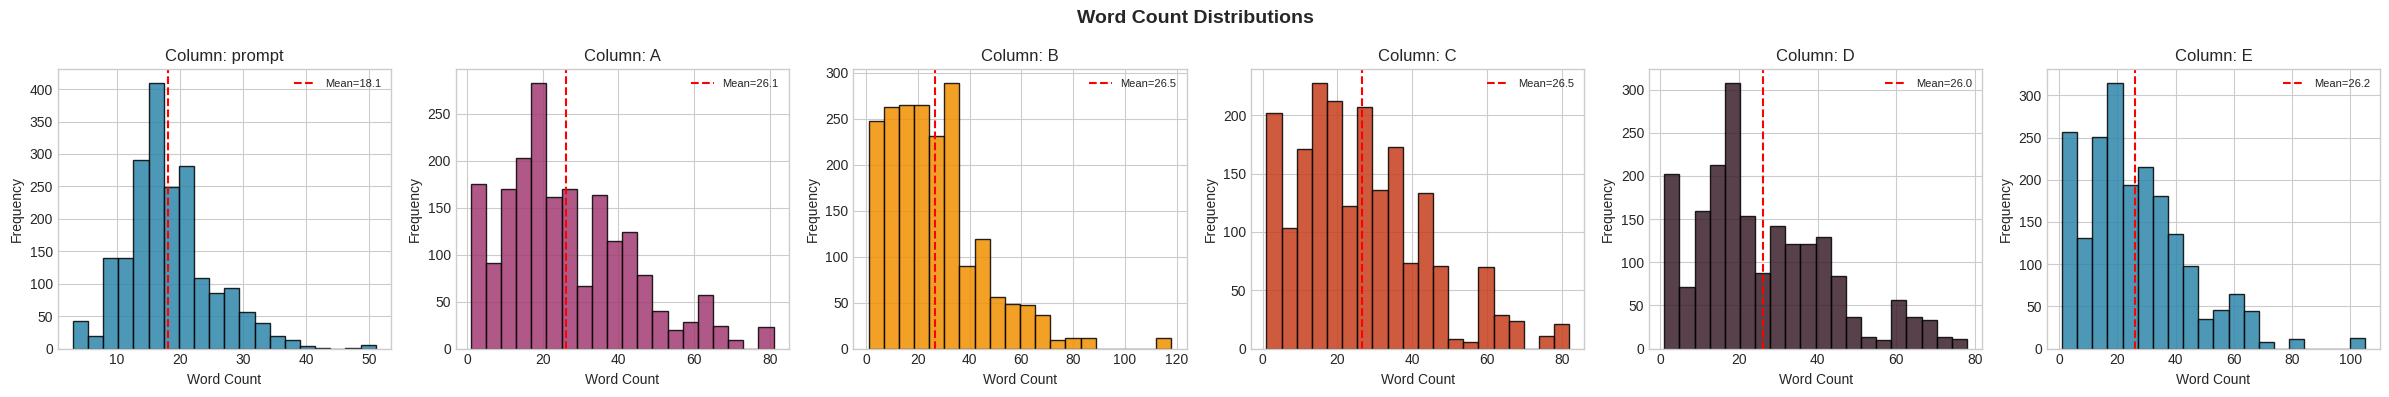

In [20]:
train_df, test_df = step_preprocessing(train_df, test_df)


STEP 4 : ANSWER DISTRIBUTION
answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64
Figure saved to outputs/answer_distribution.png


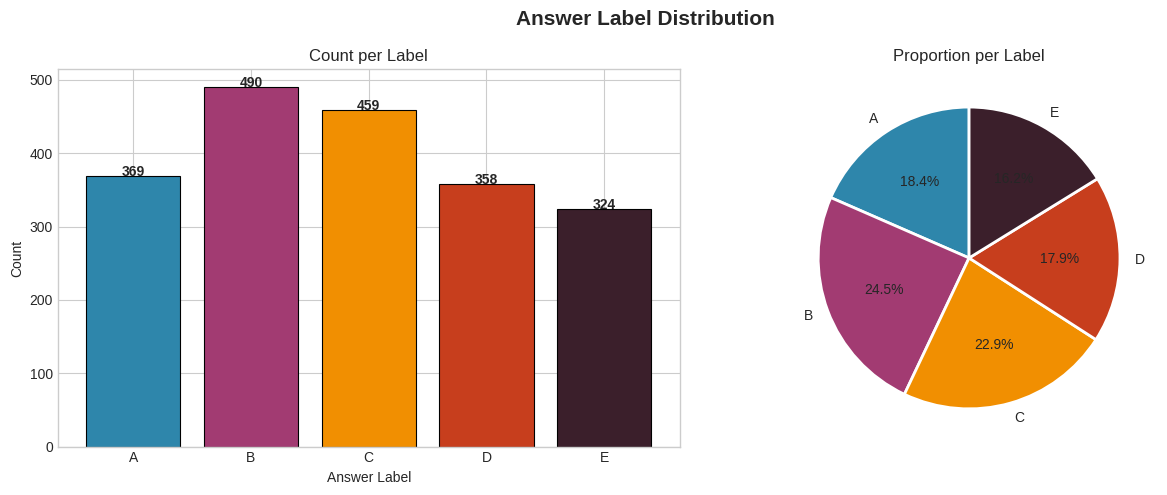

In [21]:
step_answer_distribution(train_df)


STEP 3 : WORD FREQUENCY ANALYSIS
Unique prompt tokens  : 765
Unique option tokens  : 2373
Top 10 prompt words   : [('correct', 1175), ('option', 996), ('following', 746), ('answer', 608), ('based', 414), ('among', 388), ('listed', 388), ('context', 388), ('statement', 384), ('given', 376)]
Top 10 option words   : [('used', 1205), ('light', 1184), ('time', 963), ('energy', 939), ('temperature', 920), ('particle', 904), ('object', 849), ('mass', 787), ('effect', 786), ('symmetry', 765)]
Figure saved to outputs/top_prompt_words.png


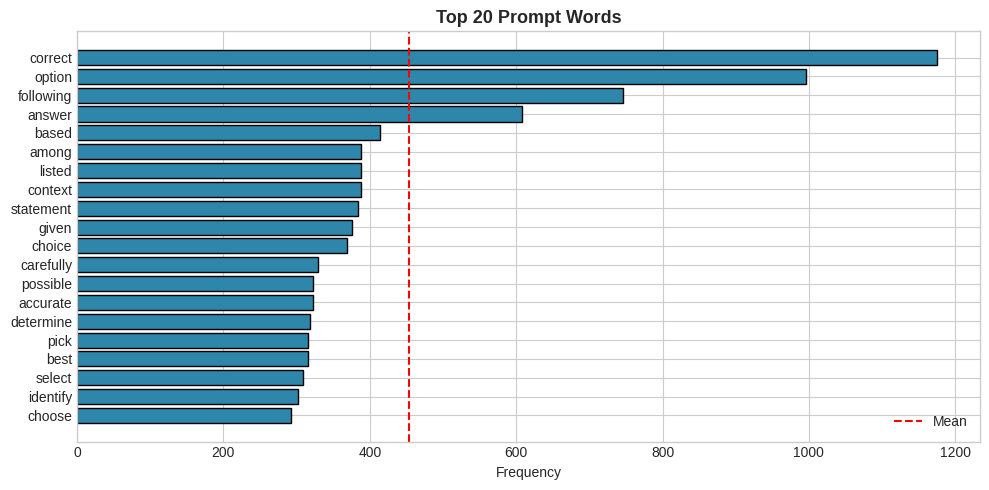

Figure saved to outputs/top_option_words.png


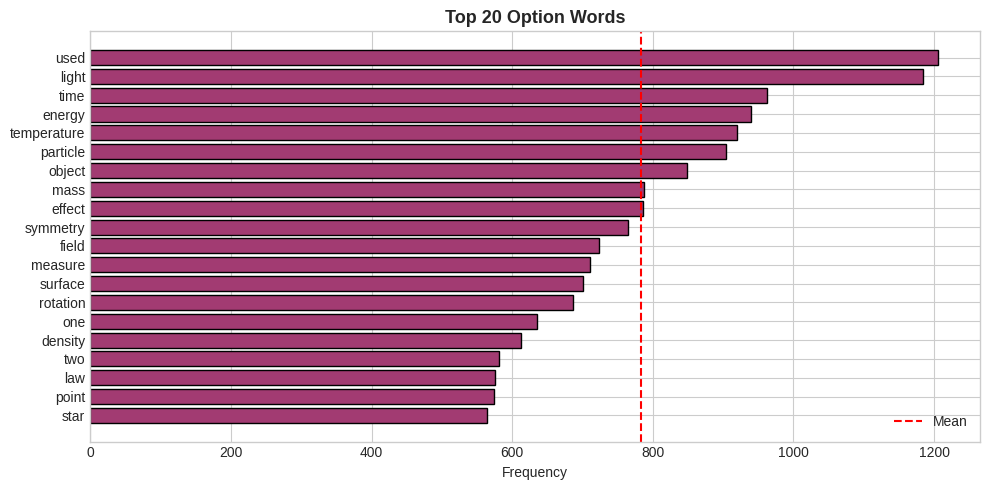

Figure saved to outputs/wordcloud_prompts.png


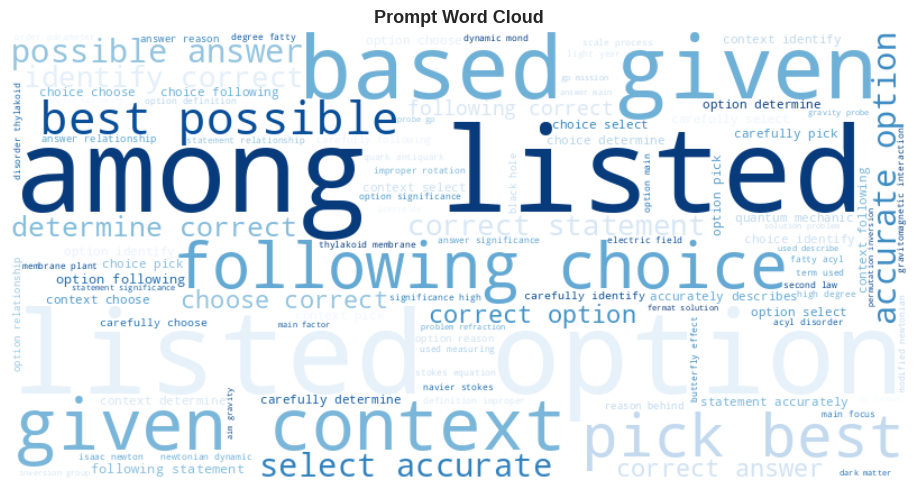

Figure saved to outputs/wordcloud_options.png


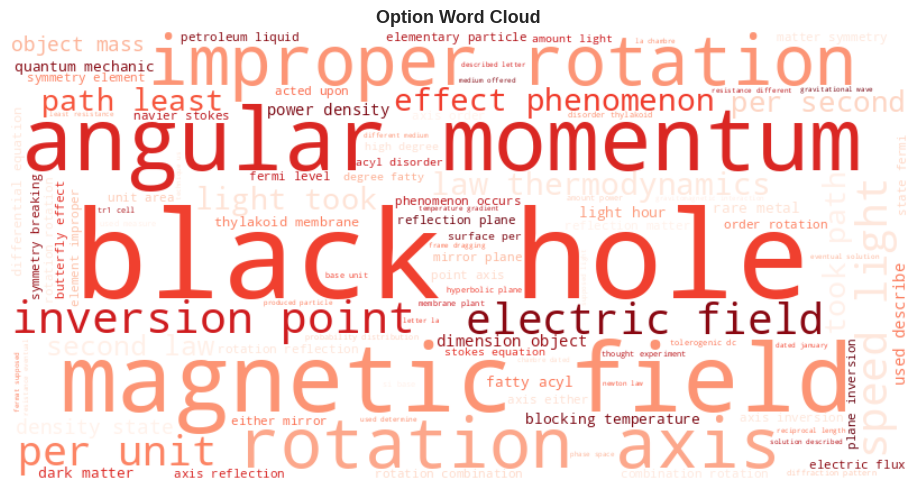

(Counter({'pick': 316,
          'best': 316,
          'possible': 323,
          'answer': 608,
          'martin': 11,
          'heidegger': 11,
          'view': 22,
          'relationship': 148,
          'time': 57,
          'human': 11,
          'existence': 23,
          'among': 388,
          'listed': 388,
          'option': 996,
          'accelerator': 8,
          'based': 414,
          'light': 55,
          'ion': 8,
          'fusion': 8,
          'determine': 319,
          'correct': 1175,
          'term': 44,
          'used': 102,
          'astrophysics': 7,
          'describe': 34,
          'matter': 47,
          'interaction': 33,
          'resulting': 7,
          'energy': 39,
          'shift': 7,
          'radiation': 7,
          'field': 58,
          'select': 309,
          'accurate': 322,
          'carefully': 329,
          'identify': 302,
          'statement': 384,
          'concept': 32,
          'simultaneity': 14,
          'eins

In [22]:
step_word_frequency(train_df)

In [23]:
tfidf_embedder = step_tfidf(train_df, test_df)


STEP 5 : TF-IDF EMBEDDINGS
TF-IDF fitted  | vocab size : 5000
Matrix shape : (2000, 5000)
Sparsity     : 98.98%

Top 10 TF-IDF Features:
  feature  mean_tfidf
  correct    0.017690
     used    0.017023
   option    0.016953
following    0.014624
     time    0.013141
  measure    0.012788
   answer    0.012663
    field    0.012600
   effect    0.012402
    light    0.012210
TF-IDF saved to models/tfidf.pkl



STEP 6 : WORD2VEC EMBEDDINGS
Total training sentences : 11870
Word2Vec trained | vocab size : 2864
  'time' similar to : [('dissimilarity', 0.6054555177688599), ('recurrent', 0.6008679866790771), ('approximate', 0.6005101799964905)]
  'fusion' similar to : [('fission', 0.8115326166152954), ('accelerator', 0.7218082547187805), ('transformer', 0.7207511067390442)]
  'energy' similar to : [('ecostructure', 0.6198617219924927), ('entered', 0.6140239238739014), ('ecomechanism', 0.6135343313217163)]
  'theory' similar to : [('principle', 0.8363576531410217), ('concept', 0.8292787671089172), ('framework', 0.7577752470970154)]
PCA | explained variance : 10.20%
Figure saved to outputs/w2v_pca.png


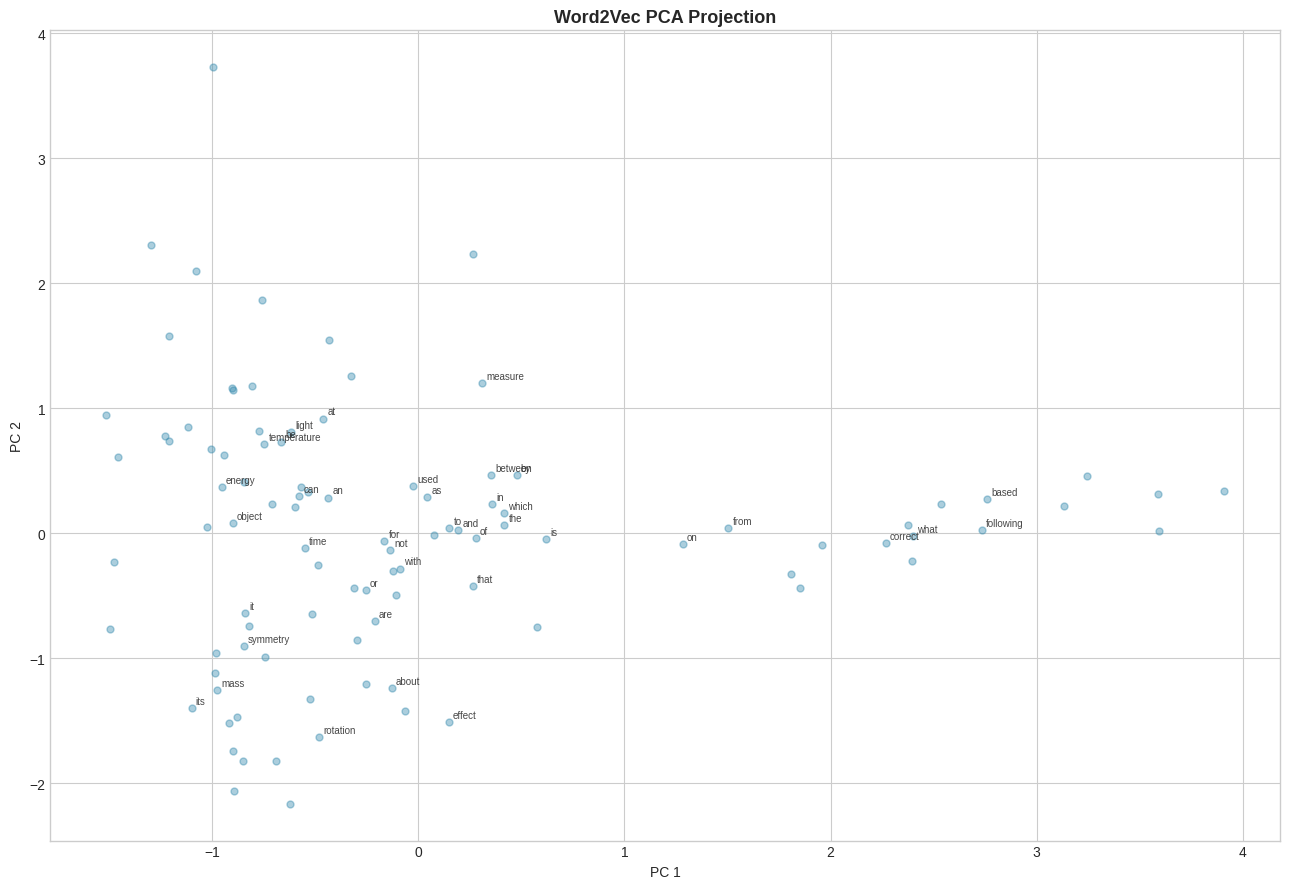

Word2Vec saved to models/w2v.model


In [24]:
w2v_embedder = step_word2vec(train_df)


STEP 7 : COSINE SIMILARITY
Computed tfidf_sim_A
Computed tfidf_sim_B
Computed tfidf_sim_C
Computed tfidf_sim_D
Computed tfidf_sim_E
Computed w2v_sim_A
Computed w2v_sim_B
Computed w2v_sim_C
Computed w2v_sim_D
Computed w2v_sim_E

TF-IDF  | Correct mean : 0.2722 | Incorrect mean : 0.2877
Word2Vec | Correct mean : 0.6485 | Incorrect mean : 0.6543
Figure saved to outputs/sim_dist_tfidf.png


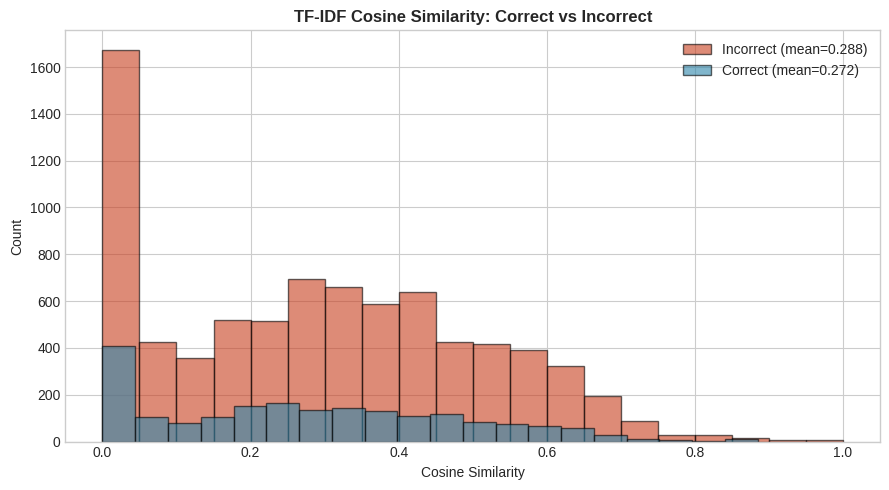

Figure saved to outputs/sim_dist_w2v.png


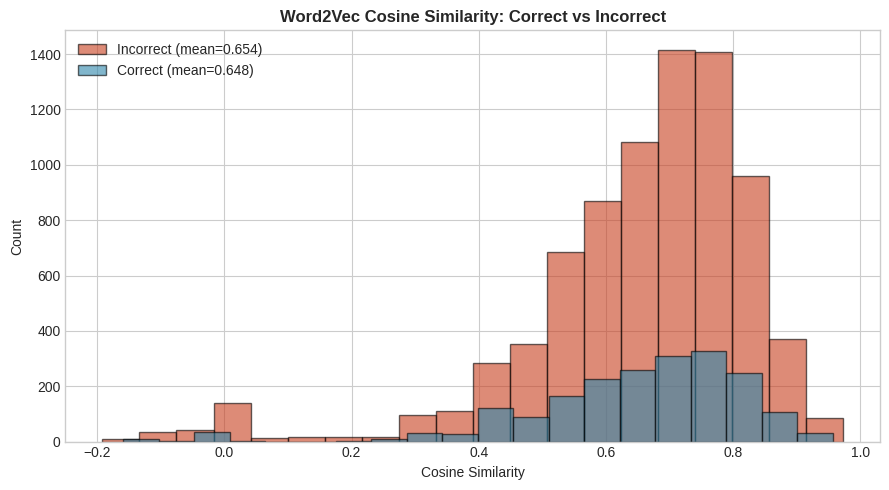

Figure saved to outputs/mean_sim_per_option.png


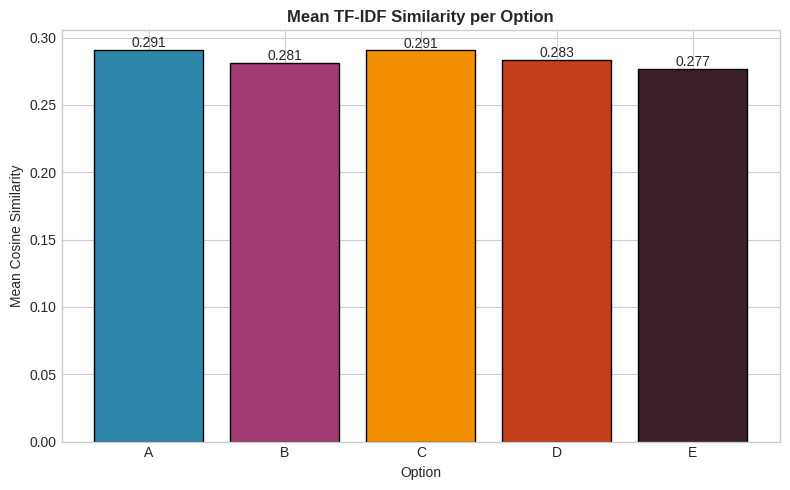

Figure saved to outputs/mean_sim_per_option_w2v.png


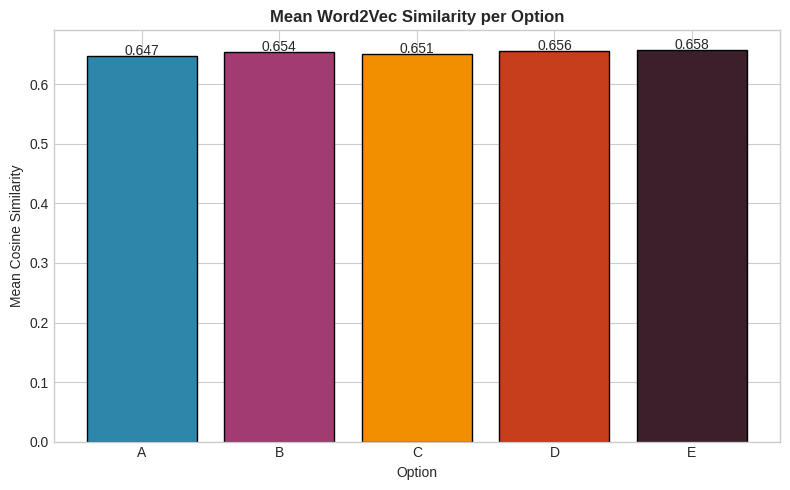

Figure saved to outputs/inter_option_heatmap.png


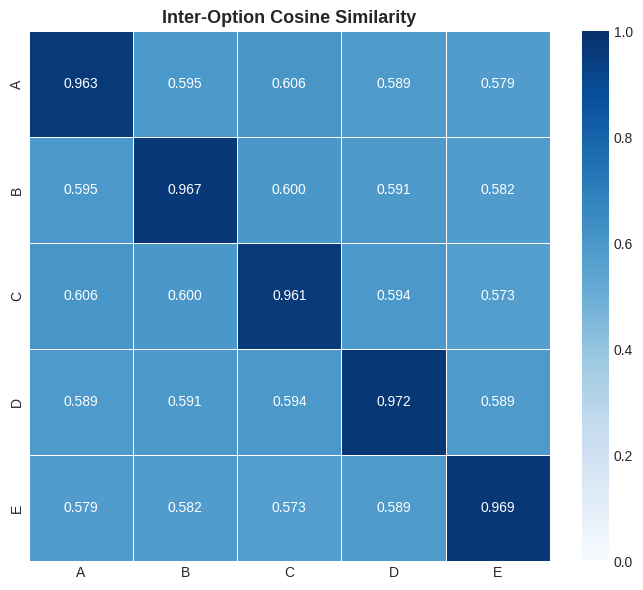

In [25]:
train_df = step_similarity(train_df, tfidf_embedder, w2v_embedder)


STEP 8 : MAP@3 EVALUATION
  Random                    MAP@3 = 0.3725
  Always_A_B_C              MAP@3 = 0.3835
  TF-IDF_cosine             MAP@3 = 0.2963
  Word2Vec_cosine           MAP@3 = 0.3068

Strategy Comparison:
       strategy  map_at_3
   Always_A_B_C    0.3835
         Random    0.3725
Word2Vec_cosine    0.3068
  TF-IDF_cosine    0.2963
Figure saved to outputs/map_comparison.png


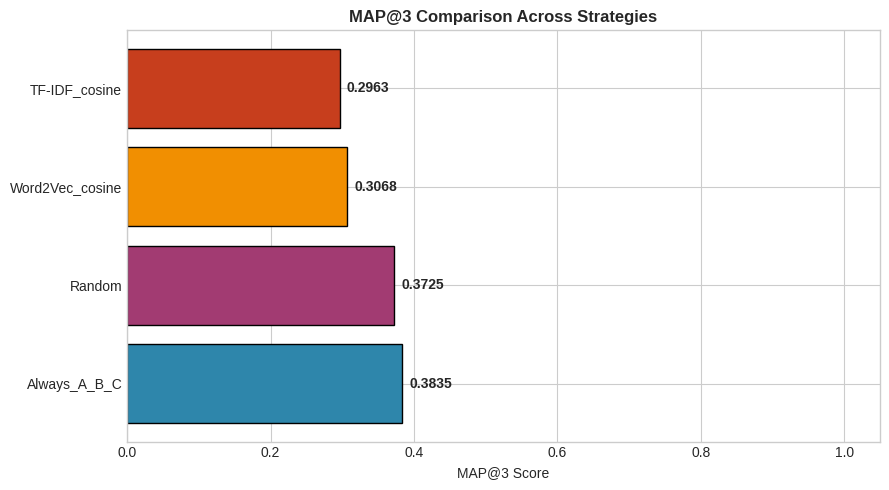


Detailed Evaluation Report (TF-IDF):
MAP@3 = 0.2962
 question_idx actual pred_1 pred_2 pred_3 correct_rank  ap_at_k
            0      B      D      C      B            3   0.3333
            1      A      C      A      B            2   0.5000
            2      C      A      B      C            3   0.3333
            3      B      D      C      B            3   0.3333
            4      A      D      E      B           >3   0.0000
            5      C      A      B      C            3   0.3333
            6      E      C      A      D           >3   0.0000
            7      A      D      C      B           >3   0.0000
            8      A      A      B      C            1   1.0000
            9      A      A      B      D            1   1.0000
           10      C      E      B      C            3   0.3333
           11      B      A      D      E           >3   0.0000
           12      D      C      A      D            3   0.3333
           13      E      E      D      A          

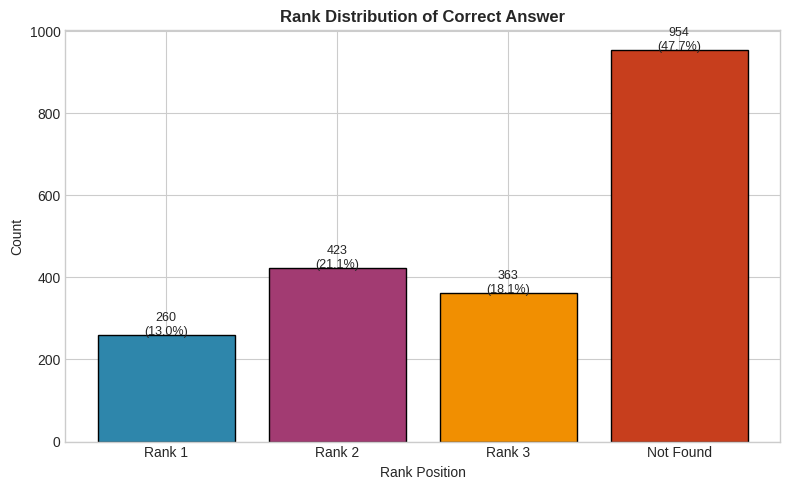

In [26]:
results_df = step_metrics(train_df)

In [27]:
print("\n" + "=" * 50)
print("EDA COMPLETE")
print("=" * 50)
print(f"All figures saved to : {OUTPUT_DIR}/")
print(f"Models saved to      : models/")


EDA COMPLETE
All figures saved to : outputs/
Models saved to      : models/


In [28]:
import pandas as pd

# Read the CSV file
df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

# Save an identical copy
df.to_csv("submission.csv", index=False)

print("File copied successfully.")

File copied successfully.
